In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pickle

from dPCA import dPCA

from imports import *
from config import dir_config, main_config, ephys_config
from src.utils import pmf_utils, plot_utils, ephys_utils
import os
os.environ["PYDEVD_WARN_SLOW_RESOLVE_TIMEOUT"] = "2.0"
import copy

In [3]:
compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

## Utils

In [7]:
def dpca_transform(dpca, X):
    X = X - np.nanmean(X.reshape((X.shape[0],-1)),1).reshape((X.shape[0],) + (len(X.shape)-1)*(1,))
    total_variance = np.sum((X - np.nanmean(X))**2)
    def marginal_variances(marginal):
        ''' Computes the relative variance explained of each component
            within a marginalization
        '''
        D, Xr = dpca.D[marginal], X.reshape((X.shape[0],-1))
        return [np.sum(np.dot(D[:,k], Xr)**2) / total_variance for k in range(D.shape[1])]

    X_transformed = {}
    dpca.explained_variance_ratio_ = {}
    for key in list(dpca.marginalizations.keys()):
        X_transformed[key] = np.dot(dpca.D[key].T, X.reshape((X.shape[0],-1))).reshape((dpca.D[key].shape[1],) + X.shape[1:])
        dpca.explained_variance_ratio_[key] = marginal_variances(key)
    return dpca, X_transformed

def create_dpca_matrix(sessions, condition_dict, session_neuron_ids, biased_state_trial_info, unbiased_state_trial_info):
    n_neurons = len(session_neuron_ids)
    n_states = len(condition_dict["state_values"])
    n_coherences = len(condition_dict["coherences"])
    n_choices = len(condition_dict["choices"])
    dPCA_averaged_data = {event: np.full([n_neurons, n_states, n_coherences, n_choices,
                                 ephys_config["alignment_settings_GP"][event]["end_time_ms"] -ephys_config["alignment_settings_GP"][event]["start_time_ms"]+1], np.nan)
                                 for event in ephys_config["alignment_settings_GP"].keys()}
    dPCA_trial_wise_data = {event: np.full([250, n_neurons, n_states, n_coherences, n_choices,
                                 ephys_config["alignment_settings_GP"][event]["end_time_ms"] -ephys_config["alignment_settings_GP"][event]["start_time_ms"]+1], np.nan)
                                 for event in ephys_config["alignment_settings_GP"].keys()}

    for alignment in ephys_config["alignment_settings_GP"].keys():
        for session_id in sessions:
            # get neurons in this session
            neuron_ids = neuron_metadata.neuron_id[neuron_metadata.session_id == session_id].values
            # extract trial numbers for each condition
            for state_idx, state in enumerate(condition_dict["state_values"]):
                if state == "biased":
                    trial_info = biased_state_trial_info
                elif state == "unbiased":
                    trial_info = unbiased_state_trial_info
                for coherence_idx, coherence in enumerate(condition_dict["coherences"]):
                    for choice_idx, choice in enumerate(condition_dict["choices"]):
                        trials = ephys_utils.get_trial_num(trial_info[session_id], coherence=coherence, choice=choice_idx, outcome=1)

                        for neuron_id in neuron_ids:
                            trial_wise_data = ephys_utils.get_neural_data_from_trial_num(ephys[alignment][neuron_id], trials, type="convolved_spike_trains")
                            if trial_wise_data.shape[0] == 0:
                                print(f"No trials found in Session: {session_id}, State: {state}, Neuron: {neuron_id}, condition: {coherence, choice}")
                                continue
                            averaged_data = np.nanmean(trial_wise_data, axis=0)

                            if alignment == "cue":
                                non_nan_timepoint = np.where(np.sum(np.isnan(trial_wise_data), axis=0)/len(trials) <= 0.7)[0]
                                averaged_data = averaged_data[:non_nan_timepoint[-1] + 1]
                                dPCA_averaged_data[alignment][np.where(session_neuron_ids == neuron_id)[0], state_idx, coherence_idx, choice_idx, 0:len(averaged_data)] = averaged_data

                            elif alignment == "response":
                                non_nan_timepoint = np.where(np.sum(np.isnan(trial_wise_data), axis=0)/len(trials) <= 0.7)[0]
                                averaged_data = averaged_data[non_nan_timepoint[0]:]
                                dPCA_averaged_data[alignment][np.where(session_neuron_ids == neuron_id)[0], state_idx, coherence_idx, choice_idx, -len(averaged_data):] = averaged_data
                            else:
                                dPCA_averaged_data[alignment][np.where(session_neuron_ids == neuron_id)[0], state_idx, coherence_idx, choice_idx, :] = averaged_data

                            dPCA_trial_wise_data[alignment][:trial_wise_data.shape[0], np.where(session_neuron_ids == neuron_id)[0], state_idx, coherence_idx, choice_idx, :] = np.expand_dims(trial_wise_data, axis=1)

    return dPCA_averaged_data, dPCA_trial_wise_data


## Load Data

In [6]:
session_to_exclude = ["210210_GP_JP","241209_GP_TZ"]

session_metadata = pd.read_csv(Path(processed_dir, 'sessions_metadata.csv'))
session_metadata = session_metadata[~np.isin(session_metadata["session_id"],session_to_exclude)]

neuron_metadata = pd.read_csv(Path(compiled_dir, 'neuron_metadata.csv'))
neuron_metadata = neuron_metadata[~np.isin(neuron_metadata["session_id"],session_to_exclude)]

with open(Path(processed_dir, f'glm_hmm_masked_final.pkl'), 'rb') as f:
    glm_hmm = pickle.load(f)
glm_hmm_original = copy.deepcopy(glm_hmm)

with open(Path(processed_dir, f'ephys_neuron_wise.pkl'), 'rb') as f:
    ephys = pickle.load(f)

## Extract biased and unbiased states, toRF and awayRF prior sessions

In [8]:
toRF_sessions = session_metadata["session_id"][session_metadata.prior_direction == "toRF"]
awayRF_sessions = session_metadata["session_id"][session_metadata.prior_direction == "awayRF"]

# extract neuron_id for each toRF session
toRF_neuron_ids = np.array([])
for session_id in toRF_sessions:
	neuron_ids = neuron_metadata.neuron_id[neuron_metadata.session_id == session_id].values
	toRF_neuron_ids = np.append(toRF_neuron_ids, neuron_ids)

# extract neuron_id for each awayRF session
awayRF_neuron_ids = np.array([])
for session_id in awayRF_sessions:
	neuron_ids = neuron_metadata.neuron_id[neuron_metadata.session_id == session_id].values
	awayRF_neuron_ids = np.append(awayRF_neuron_ids, neuron_ids)

In [9]:
data = glm_hmm["data"]
n_trial_back = 1
for session_id in data:
    trial_data = pd.read_csv(Path(compiled_dir, session_id, f"{session_id}_trial.csv"), index_col=None)
    GP_trial_data = trial_data[trial_data.task_type == 1].reset_index(drop=True)
    # Get valid indices based on outcomes
    valid_idx = np.where(GP_trial_data.outcome >= 0)[0]
	# First valid trial considering n_trial_back
    first_trial = valid_idx[n_trial_back - 1] + 1
    reaction_time = np.array(GP_trial_data.reaction_time)[first_trial:]
    data[session_id]["reaction_time"] = reaction_time


In [10]:
confidence_threshold = 0.8
state_occupancy = {}
biased_state_trial_info = {}
unbiased_state_trial_info = {}

for session_id in (session_metadata["session_id"]):
	model = glm_hmm_original["model"]["models"][session_id]
	choices = glm_hmm_original["data"][session_id]["choices"].values.reshape(-1, 1)
	input = np.array(glm_hmm_original["data"][session_id][["normalized_stimulus", "bias", "prev_choice_1", "prev_target_1"]])
	if glm_hmm_original["data"][session_id]["mask"] is None:
		mask = None
	else:
		mask = glm_hmm_original["data"][session_id]["mask"]
	mask = np.ones_like(choices, dtype=bool) if mask is None else mask

	posterior_probs = model.expected_states(data=choices, input=input, mask=np.array(mask).reshape(-1, 1))[0]
	biased_idx = (posterior_probs[:, 0] > confidence_threshold) & np.array(mask)
	unbiased_idx = (posterior_probs[:, 1] > confidence_threshold) & np.array(mask)
	state_occupancy[session_id] = {"biased_state_trials": glm_hmm_original["data"][session_id]["trial_num"][biased_idx], "unbiased_state_trials": glm_hmm_original["data"][session_id]["trial_num"][unbiased_idx]}

	#flip back to toRF/awayRF for inputs in dPCA
	if session_metadata["prior_direction"][session_metadata["session_id"] == session_id].values[0] == "awayRF":
		data[session_id]["choices"] = 1 - data[session_id]["choices"]
		data[session_id]["stimulus"] = -data[session_id]["stimulus"]
		data[session_id]["normalized_stimulus"] = -data[session_id]["normalized_stimulus"]
		data[session_id]["prev_choice_1"] = -data[session_id]["prev_choice_1"]
		data[session_id]["prev_target_1"] = -data[session_id]["prev_target_1"]

	biased_state_trials = state_occupancy[session_id]["biased_state_trials"]
	biased_state_trial_info[session_id] = data[session_id].loc[np.isin(data[session_id]["trial_num"], biased_state_trials)]
	unbiased_state_trials = state_occupancy[session_id]["unbiased_state_trials"]
	unbiased_state_trial_info[session_id] = data[session_id].loc[np.isin(data[session_id]["trial_num"], unbiased_state_trials)]

## dPCA

### Prepare trial-averaged data and trial-wise data

In [11]:
condition_dict = {
	"state_values": ["biased", "unbiased"],
	"coherences": [0, 0.06, 0.2, 0.5],
	"choices": ["awayRF", "toRF"],
}

In [12]:
dPCA_averaged_data = {"toRF_prior": {}, "awayRF_prior": {}}
dPCA_trial_wise_data = {"toRF_prior": {}, "awayRF_prior": {}}
dPCA_averaged_full_data = {"toRF_prior": {}, "awayRF_prior": {}}
dPCA_trial_wise_full_data = {"toRF_prior": {}, "awayRF_prior": {}}

for prior_idx, prior in enumerate(["toRF_prior","awayRF_prior"]):
    sessions = awayRF_sessions if prior_idx else toRF_sessions
    neuron_ids = awayRF_neuron_ids if prior_idx else toRF_neuron_ids
    dPCA_averaged_data[prior], dPCA_trial_wise_data[prior] = create_dpca_matrix(sessions, condition_dict, neuron_ids, biased_state_trial_info, unbiased_state_trial_info)
    dPCA_averaged_full_data[prior] = dPCA_averaged_data[prior].copy()
    dPCA_trial_wise_full_data[prior] = dPCA_trial_wise_data[prior].copy()

    for alignment in ephys_config["alignment_settings_GP"].keys():
       # remove timepoints with any nan in average data to fit with dpca
        no_any_nan_mask = ~np.any(np.isnan(dPCA_averaged_data[prior][alignment]), axis=(0, 1, 2, 3))
        dPCA_averaged_data[prior][alignment] = dPCA_averaged_data[prior][alignment][..., no_any_nan_mask]
        dPCA_trial_wise_data[prior][alignment] = dPCA_trial_wise_data[prior][alignment][..., no_any_nan_mask]

        # remove timepoints with all nans in full data
        # used for shuffling
        no_all_nan_mask = ~np.all(np.isnan(dPCA_averaged_full_data[prior][alignment]), axis=(0, 1, 2, 3))
        dPCA_averaged_full_data[prior][alignment] = dPCA_averaged_full_data[prior][alignment][..., no_all_nan_mask]
        dPCA_trial_wise_full_data[prior][alignment] = dPCA_trial_wise_full_data[prior][alignment][..., no_all_nan_mask]

        # remove nan trials in trial-wise data (including full data)
        nonnan_trial_mask = ~np.all(np.isnan(dPCA_trial_wise_data[prior][alignment]), axis=(1, 2, 3, 4, 5))
        dPCA_trial_wise_data[prior][alignment] = dPCA_trial_wise_data[prior][alignment][nonnan_trial_mask, ...]
        dPCA_trial_wise_full_data[prior][alignment] = dPCA_trial_wise_full_data[prior][alignment][nonnan_trial_mask, ...]


### dpca fit

In [13]:
marginalization_keys = ['b', 's', 'c', 't']
n_components = 3
dpca_results = {"toRF_prior": {}, "awayRF_prior": {}}

for prior_idx, prior in enumerate(["toRF_prior", "awayRF_prior"]):
    for alignment in ephys_config["alignment_settings_GP"]:
        dpca = dPCA.dPCA(n_components=n_components, labels=''.join(marginalization_keys), regularizer=0) # 4 features: state bias b, stimulus s, choice c, timepoint t
        dpca.protect = ['t']

        dpca.fit(dPCA_averaged_data[prior][alignment], dPCA_trial_wise_data[prior][alignment])

        X = dPCA_averaged_data[prior][alignment]
        # X = dPCA_averaged_full_data[prior][alignment]
        dpca, Z = dpca_transform(dpca, X)
        dpca_results[prior][alignment] = {"model": dpca, "transformed_data": Z}

### Explained Variance

In [14]:
explained_variance_ratio = {
        "toRF_prior": {alignment: dpca_results["toRF_prior"][alignment]["model"].explained_variance_ratio_ for alignment in ephys_config["alignment_settings_GP"].keys()},
        "awayRF_prior": {alignment: dpca_results["awayRF_prior"][alignment]["model"].explained_variance_ratio_ for alignment in ephys_config["alignment_settings_GP"].keys()}
    }

Prior: toRF


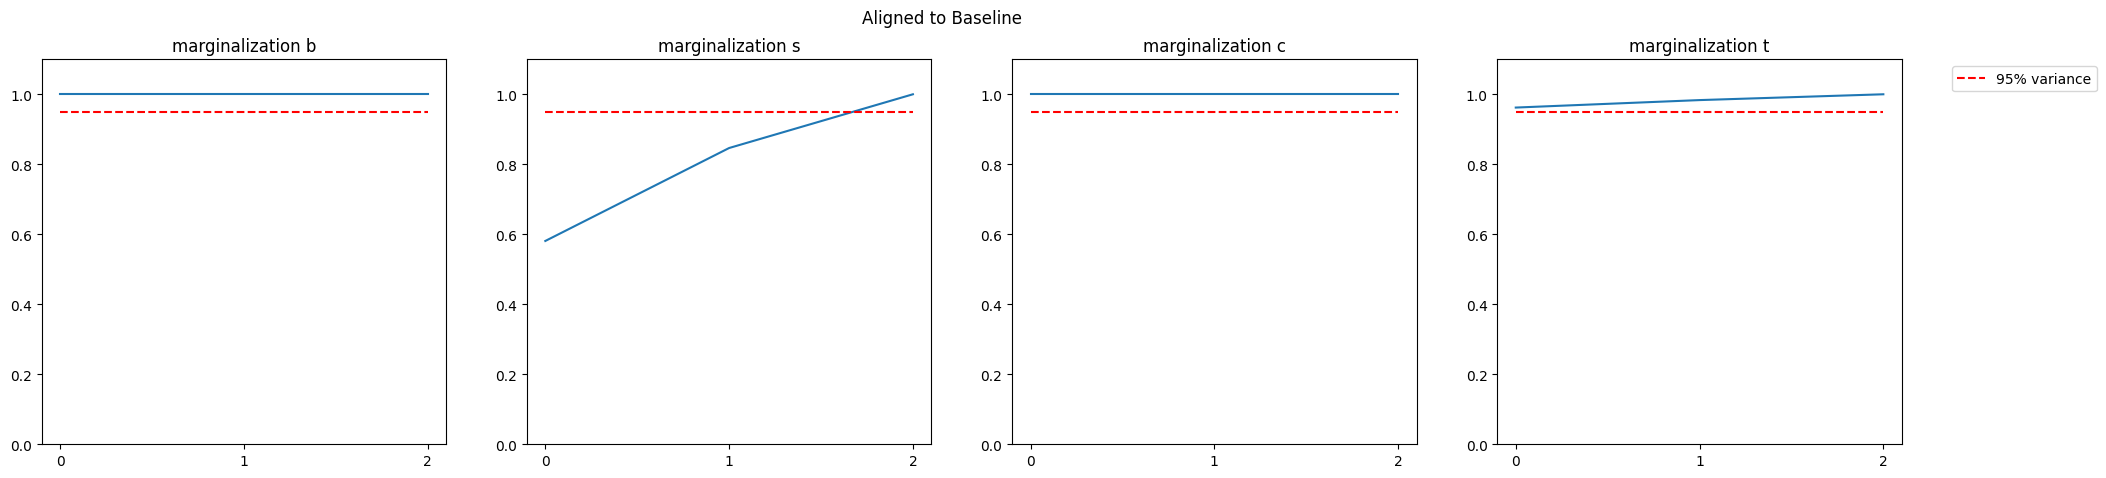

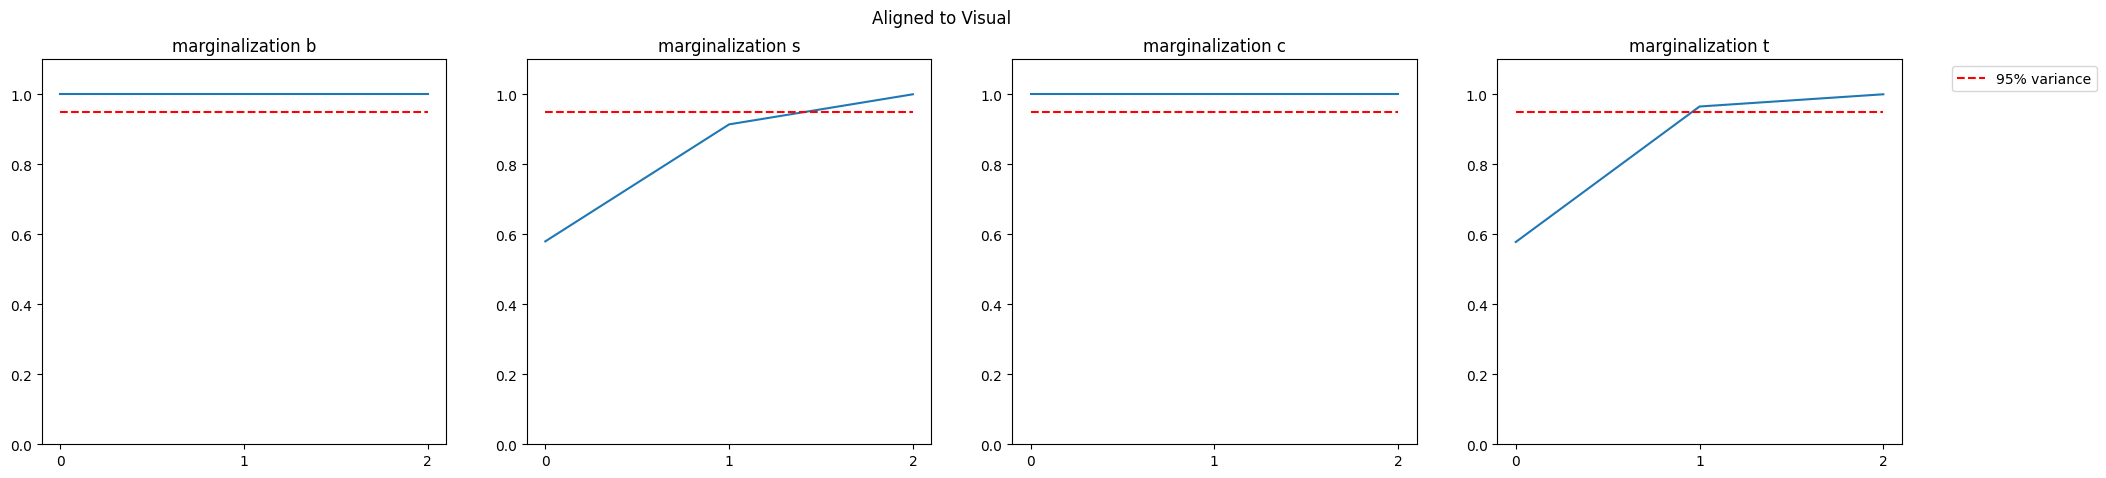

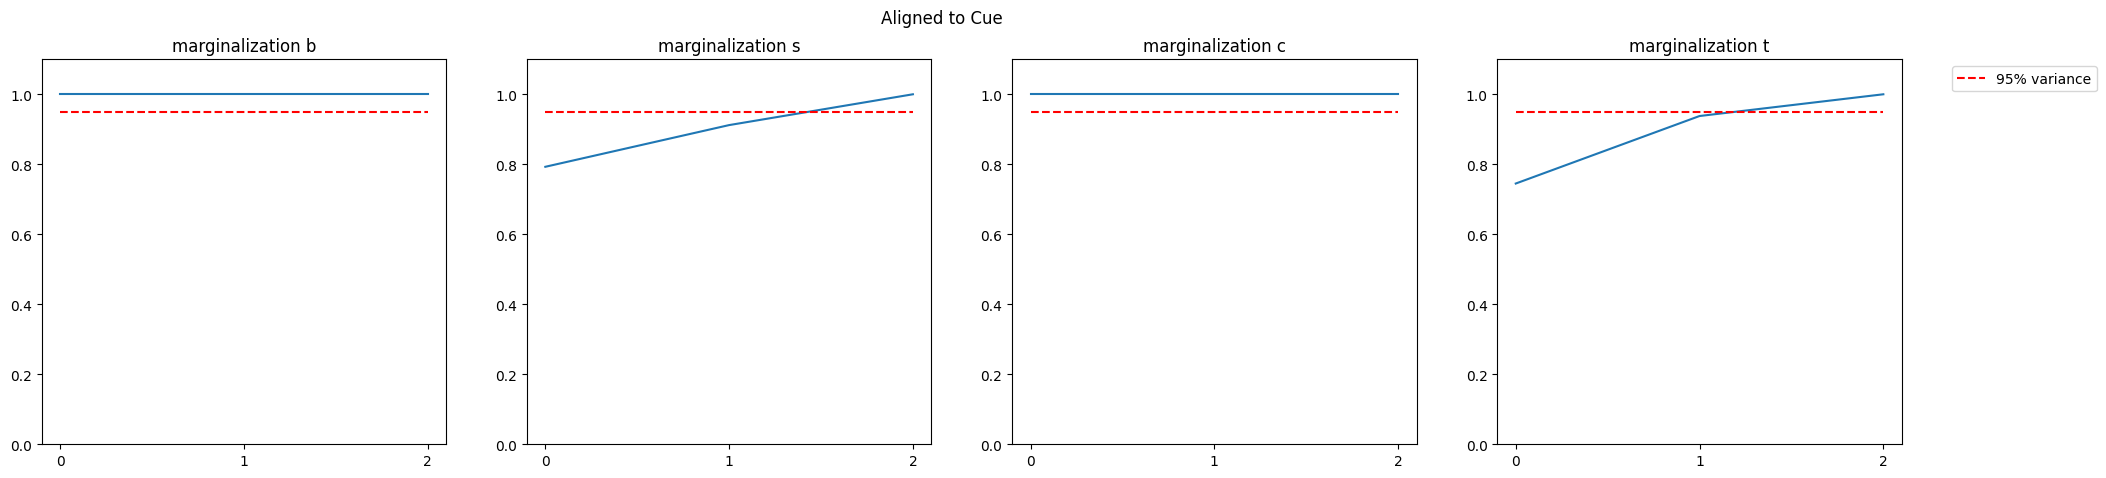

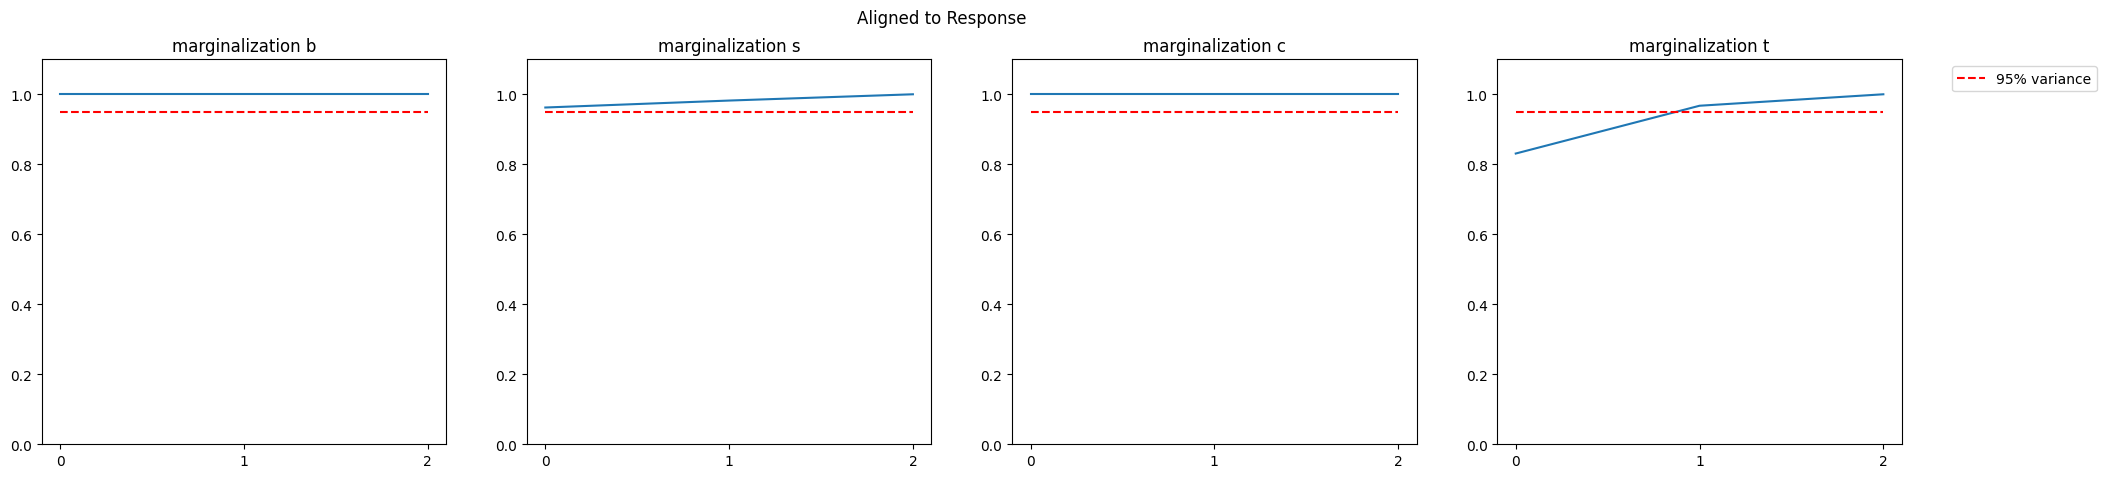

Prior: awayRF


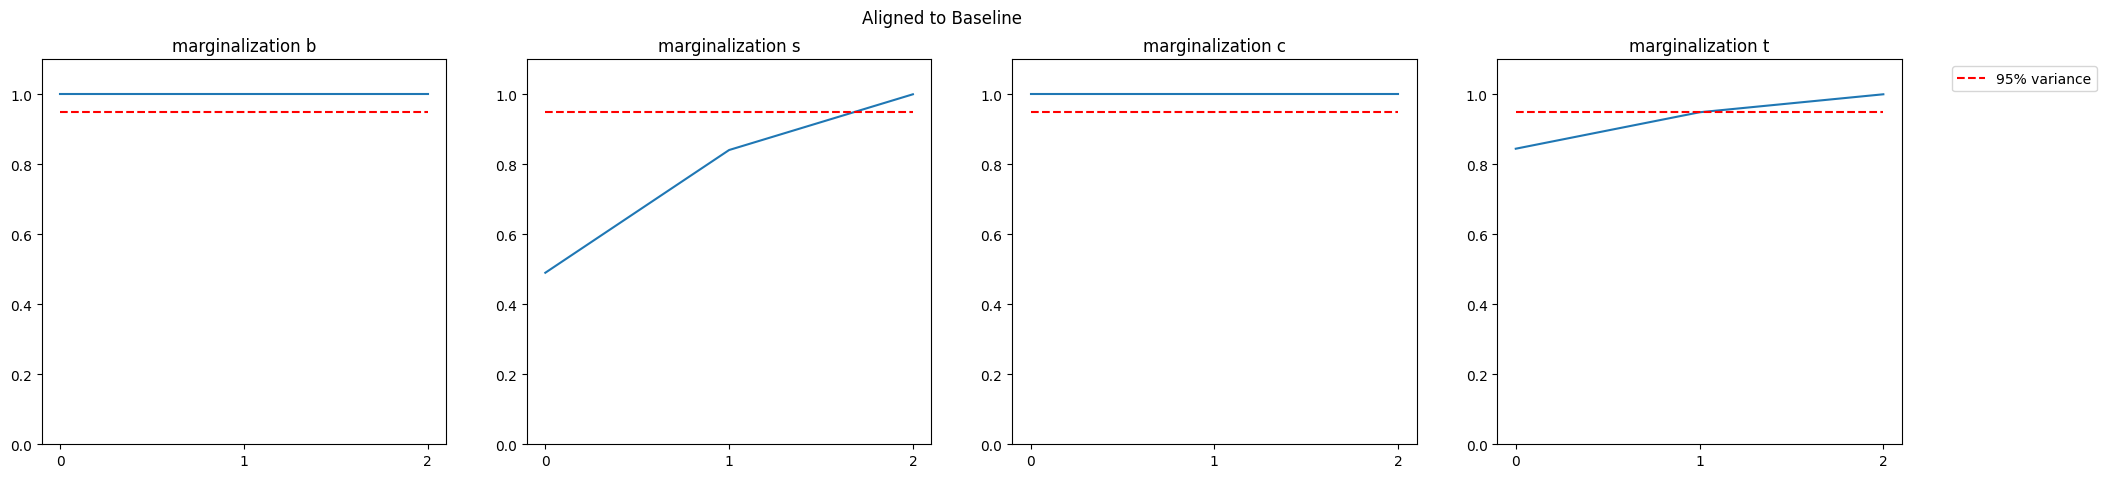

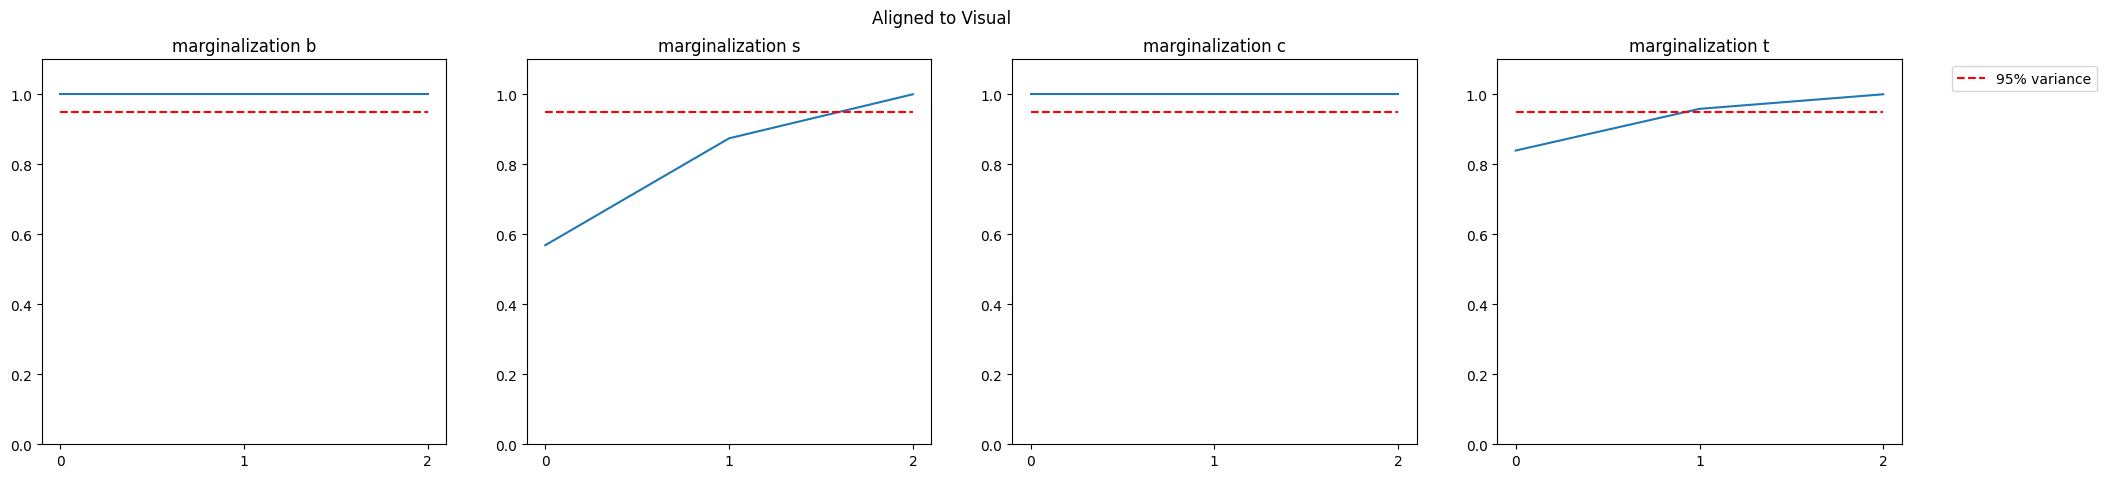

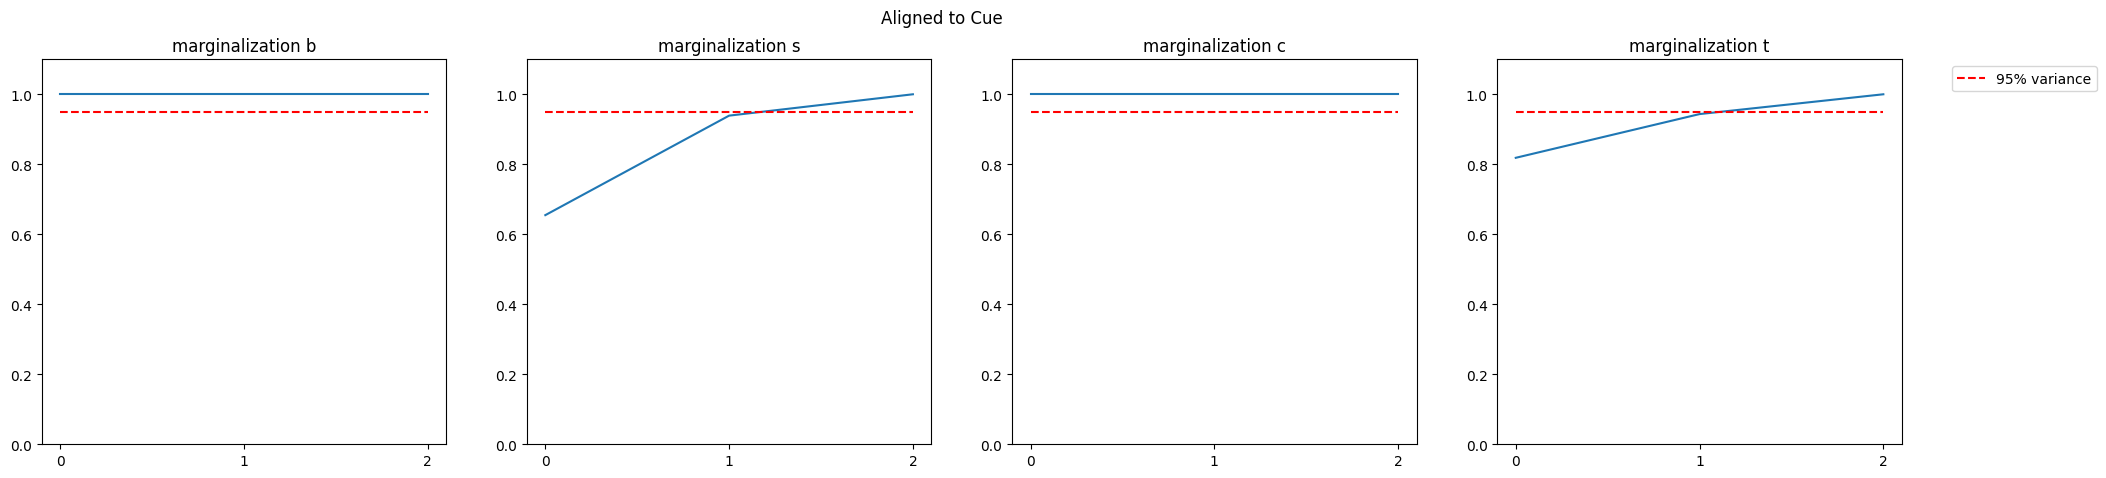

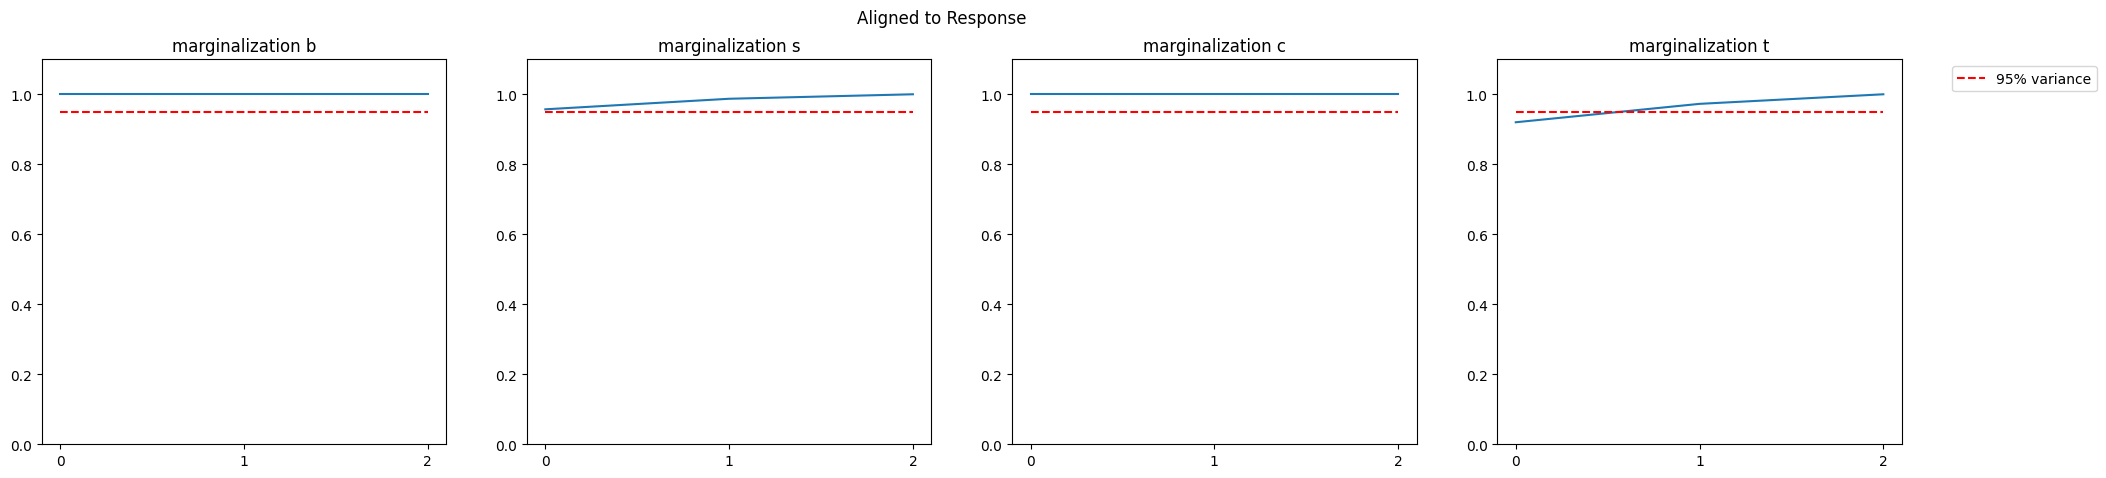

In [15]:
for prior in ["toRF_prior","awayRF_prior"]:
    print(f"Prior: {prior.split('_')[0]}")
    for alignment in ephys_config["alignment_settings_GP"].keys():
        plt.figure(figsize=(24,5))
        for marg_idx, marginalization in enumerate(marginalization_keys):
            plt.subplot(1,len(marginalization_keys),marg_idx+1)
            plt.plot(np.cumsum(explained_variance_ratio[prior][alignment][marginalization])/np.sum(explained_variance_ratio[prior][alignment][marginalization]))
            plt.xticks(np.arange(n_components))
            plt.ylim([0,1.1])
            plt.title(f"marginalization {marginalization}")
            plt.hlines(0.95,0,n_components-1,linestyles='dashed',colors='r')
        plt.suptitle(f"Aligned to {alignment.capitalize().replace('_', ' ')}")
        handle = plt.Line2D([], [], color='r', linestyle="--", label="95% variance")
        plt.legend(handles=[handle], bbox_to_anchor=(1.5, 1), loc='upper right')
        plt.show()

### project onto whole-trial activity

In [15]:
dpca_results[prior].keys()

dict_keys(['baseline', 'visual', 'cue', 'response'])

In [16]:
baseline_projection = {"toRF_prior": {}, "awayRF_prior": {}}
visual_projection = {"toRF_prior": {}, "awayRF_prior": {}}
cue_projection = {"toRF_prior": {}, "awayRF_prior": {}}
response_projection = {"toRF_prior": {}, "awayRF_prior": {}}

# for prior_idx, prior in enumerate(["toRF_prior", "awayRF_prior"]):
#     target_onset_projection[prior]["model"] = dpca_results[prior]["target_onset"]["model"]
#     stimulus_onset_projection[prior]["model"] = dpca_results[prior]["stimulus_onset"]["model"]
#     response_onset_projection[prior]["model"] = dpca_results[prior]["response_onset"]["model"]

for prior_idx, prior in enumerate(["toRF_prior", "awayRF_prior"]):
    baseline_projection[prior]["model"] = dpca_results[prior]["baseline"]["model"]
    visual_projection[prior]["model"] = dpca_results[prior]["visual"]["model"]
    cue_projection[prior]["model"] = dpca_results[prior]["cue"]["model"]
    response_projection[prior]["model"] = dpca_results[prior]["response"]["model"]

    for alignment in ephys_config["alignment_settings_GP"]:

        X = dPCA_averaged_full_data[prior][alignment]
        # X = dPCA_averaged_full_data[prior][alignment]
        _, baseline_projection[prior][alignment] = dpca_transform(baseline_projection[prior]["model"], X)
        _, visual_projection[prior][alignment] = dpca_transform(visual_projection[prior]["model"], X)
        _, cue_projection[prior][alignment] = dpca_transform(cue_projection[prior]["model"], X)
        _, response_projection[prior][alignment] = dpca_transform(response_projection[prior]["model"], X)


In [ ]:
dpca_data_and_projection = {
    "data": {
        "average": dPCA_averaged_data,
        "trial_wise": dPCA_trial_wise_data,
        "average_full": dPCA_averaged_full_data,
        "trial_wise_full": dPCA_trial_wise_full_data
        },
    "projection":{
        "baseline": baseline_projection,
        "visual": visual_projection,
        "cue": cue_projection,
        "response": response_projection,
        },
    "explained_variance_ratio": explained_variance_ratio,
}

with open(Path(processed_dir, f'dpca_data_and_projection.pkl'), 'wb') as f:
    pickle.dump(dpca_data_and_projection, f)